/var/folders/r5/rsf8hcnx2y7dwj5vskv877j00000gn/T/ipykernel_66476/1096796301.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C_b[i+1]=r.integrate(z[i+1])


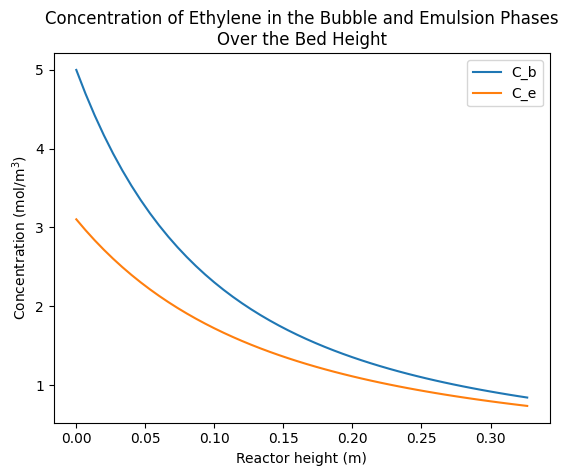

The bed height is 0.3265832415868116 m
The minimum fluidization velocity is 0.015 m/s
The bubble fraction is 0.14263818731319977
cb0 = 5.0, cbf = 0.841453707284681, ce0 = 3.103622766830249, cef = 0.7350758602504008


In [27]:
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

g = 9.81            #gravitational acceleration [m/s2]
rho_s = 2850        #Solid particle density [kg/m3]
rho_g = 1.28        #Gas density [kg/m3]
u = 0.15            #Superficial gas velocity [m/s]
mu=1.8e-5           #Viscosity of fluidization gas [Pa*s]
H_mf = 0.28        #Bed height at u_mf [m]
d_p = 60e-6         #Particle diameter [m]
D_r = 0.3           #Diameter of reactor [m]
A_r=np.pi*D_r**2/4  #Bottom surface area of reactor [m2]
D = 0.06            #Diffusion coefficient [m2/s]
gamma = 0.43        #Fraction of solids in the emulsion phase [-]
K_r=1.8             #Reaction rate constant [m6/(mol2*s)]
epsilon_mf = 0.61   #Bed voidage at u_mf [-]
phi_s= 0.83         #Sphericity of catalyst [-]
C_b0= 5             #Concentration in feed [mol/m3]

#ANSWER
u_mf = 0.015        #Minimum fluidization velocity [m/s]


#Equations to calculate bubble rise velocity
db0  = 2.78/g*(u-u_mf)**2                                        #Initial bubble diameter [m]
d_b  = 0.14*rho_s*d_p*u/u_mf*H_mf/2+db0                          #Average bubble diameter [m] 
V_b = A_r*(u-u_mf)                                               #Visible bubble flow [m3/s]
v = 3.2*D_r**(1/3)                                               #Emperical constant 
u_b = V_b+0.71*v*np.sqrt(g*d_b)                                  #Bubble velocity [m/s]
d_bm = 0.65*(np.pi/4*(D_r*100)**2*(u-u_mf)*100)**0.4/100         #Maximum bubble diameter [m]
if d_b>d_bm:
    d_b = d_bm
    


H_b = H_mf /(1-(u-u_mf)/u_b)          #Bed height [m]
epsilon_b= (u-u_mf)/u_b    #Bubble fraction [-]

K = u_mf/3+np.sqrt(4*D*epsilon_mf*u_b/(np.pi*d_b))*6*epsilon_b/d_b     #Mass transfer coefficient [1/s]

alpha = epsilon_b/(1-epsilon_b)*K/gamma/K_r

def dC_bdz (z, C_b): 
    # dC_bdz       = -K/u_b*(C_b-C_e)
    dC_bdz       = -K/u_b*(C_b-(0.5*(-alpha+np.sqrt(alpha**2+4*alpha*C_b))))
    return dC_bdz

#Solving the differential equation
z =np.linspace(0,H_b,50)
C_b= np.zeros(len(z))
C_b[0]=C_b0
C_e=np.zeros(len(z))
r = integrate.ode(dC_bdz).set_integrator("dopri5")
r.set_initial_value(C_b0)
for i in range(len(z)-1):
    C_b[i+1]=r.integrate(z[i+1])
    if not r.successful():
        raise RuntimeError("Could not integrate")

#Solving for C_e
for i in range (len(z)):
    C_e[i]= 0.5*(-alpha+(alpha**2+4*alpha*C_b[i])**0.5)
    
plt.plot(z,C_b, label='C_b')
plt.plot(z,C_e, label='C_e')
plt.ylabel('Concentration (mol/m$^{3}$)')
plt.xlabel('Reactor height (m)')
plt.legend(loc='upper right')
plt.title('Concentration of Ethylene in the Bubble and Emulsion Phases\n'
          'Over the Bed Height')
plt.show()

print('The bed height is',H_b,'m')
print('The minimum fluidization velocity is',u_mf,'m/s')
print('The bubble fraction is',epsilon_b)
print(f'cb0 = {C_b[0]}, cbf = {C_b[-1]}, ce0 = {C_e[0]}, cef = {C_e[-1]}')

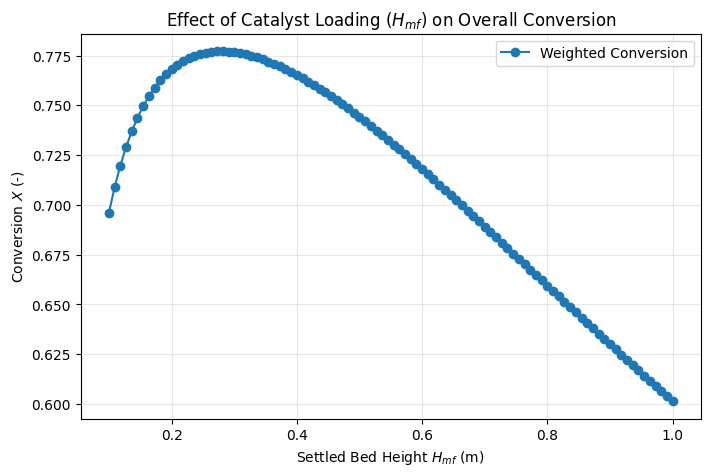

Max Conversion achieved: 77.72% at H_mf = 0.28 m


In [28]:
# Define a range of H_mf values to test
H_mf_list = np.linspace(0.1, 1, 100)
X_list = []

for h_val in H_mf_list:
    # Recalculate H_mf dependent variables
    d_b_val = 0.14*rho_s*d_p*u/u_mf*h_val/2 + db0
    if d_b_val > d_bm:
        d_b_val = d_bm
        
    u_b_val = V_b + 0.71*v*np.sqrt(g*d_b_val)
    H_b_val = h_val / (1 - (u - u_mf)/u_b_val)
    eps_b_val = (u - u_mf) / u_b_val
    
    K_val = u_mf/3 + np.sqrt(4*D*epsilon_mf*u_b_val/(np.pi*d_b_val)) * 6*eps_b_val/d_b_val
    alpha_val = eps_b_val / (1 - eps_b_val) * K_val / (gamma * K_r)
    
    # ODE for this specific H_mf
    def dCb_dz_temp(z, Cb):
        Ce_local = 0.5 * (-alpha_val + np.sqrt(alpha_val**2 + 4 * alpha_val * Cb))
        return -K_val / u_b_val * (Cb - Ce_local)
    
    sol = integrate.solve_ivp(dCb_dz_temp, [0, H_b_val], [C_b0], method='RK45')
    Cb_f = sol.y[0][-1]
    
    # Calculate phase concentrations
    Ce_in = 0.5 * (-alpha_val + np.sqrt(alpha_val**2 + 4 * alpha_val * C_b0))
    Ce_f = 0.5 * (-alpha_val + np.sqrt(alpha_val**2 + 4 * alpha_val * Cb_f))
    
    # Conversion formula provided by user
    delta_Cb = C_b0 - Cb_f
    delta_Ce = Ce_in - Ce_f
    
    num = (delta_Cb * eps_b_val) + (delta_Ce * (1 - eps_b_val))
    den = (C_b0 * eps_b_val) + (Ce_in * (1 - eps_b_val))
    
    X_list.append(num / den)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(H_mf_list, X_list, 'o-', label='Weighted Conversion')
plt.xlabel('Settled Bed Height $H_{mf}$ (m)')
plt.ylabel('Conversion $X$ (-)')
plt.title('Effect of Catalyst Loading ($H_{mf}$) on Overall Conversion')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Max Conversion achieved: {max(X_list)*100:.2f}% at H_mf = {H_mf_list[np.argmax(X_list)]:.2f} m")